# Group Homework 2 · GoMart deliveries
**Data Visualization · UEH · Session 2** · team notebook

| | |
|---|---|
| **Team** | *team name* |
| **Status** | Formative: written feedback with the rubric in the brief (first step of the group project) |
| **Submit** | File ▸ Download ▸ .ipynb as `GH2_TeamName.ipynb`, within 7 days on the LMS |

Read the brief *Group Homework 2 · GoMart* first. All data is simulated.

## Memo to the operations manager (Task 6, write this last)
**Big Idea:** *one complete sentence: your point and what is at stake.*

*At most 120 words. Put your explanatory chart in the cell below.*

In [ ]:
# Task 6: your explanatory chart goes here (copy it from Task 5 and make it explanatory)

## Task 0 · Team card
**Team name:** *(to agree)*

| Student ID | Name | Role |
|---|---|---|
| 31221020403 | Phạm Tuấn Anh | |
| 31241027205 | Trần Nhã Đoan | |
| 31221021575 | Nguyễn Hoàng Minh | Leader |
| 31221021576 | Phạm Quang Minh | |
| 31241021154 | Nguyễn Minh Nguyệt | |
| 31241026554 | Trần Nguyễn Thanh Thảo | |

**Candidate project datasets**

| # | Dataset and source | Data abstraction | Two questions as tasks (action + target) |
|---|---|---|---|
| 1 | **World Development Indicators**, World Bank Open Data ([data.worldbank.org](https://data.worldbank.org/indicator/IT.NET.USER.ZS)) | Multidimensional table, static: keys *country* + *year*; values are quantitative indicators such as internet users (% of population) and GDP per capita. | *Summarize* the *trend* of internet use in Viet Nam and its ASEAN neighbours, 2000–2024. · *Discover* the *correlation* between GDP per capita and internet use across ASEAN countries. |
| 2 | **Brazilian E-Commerce Public Dataset by Olist**, Kaggle ([kaggle.com/datasets/olistbr/brazilian-ecommerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)) | Several flat tables linked by keys (*order_id*, *customer_id*), static, about 99,000 orders 2016–2018: delivery timestamps (quantitative), review score 1–5 (ordinal), customer state (categorical). | *Discover* the *dependency* of the review score on late delivery. · *Compare* the *distribution* of delivery time across customer states. |
| 3 | **Provincial statistics of Viet Nam**, National Statistics Office, formerly GSO ([nso.gov.vn](https://www.nso.gov.vn)) | Multidimensional table, static: keys *province* + *year*; values such as population and monthly income per capita (quantitative); region (categorical). Can be joined to province boundaries (geometry) for a map. | *Compare* the *extremes* of income per capita across provinces. · *Summarize* the *trend* of income by region. Check first: provinces were merged in 2025, so tables may use different province lists. |

## Setup
In the repo the data is read from `data/raw`. In Colab, upload `gomart_orders_2025.csv` and `gomart_districts.csv` first (folder icon on the left, or `files.upload()`).

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# In the repo the files are in data/raw; in Colab, upload both files next to the notebook
DATA_DIR = next((p for p in [Path("../../data/raw"), Path("data/raw"), Path(".")]
                 if (p / "gomart_orders_2025.csv").exists()), None)
assert DATA_DIR is not None, "Upload gomart_orders_2025.csv and gomart_districts.csv first"
# The clean CSV (Task 4) is saved next to this file, or in the working folder in Colab
HERE = Path(__file__).parent if "__file__" in globals() else Path(".")
raw = pd.read_csv(DATA_DIR / "gomart_orders_2025.csv")
districts = pd.read_csv(DATA_DIR / "gomart_districts.csv")
print("orders:", raw.shape, "| districts:", districts.shape)

## Task 1 · Look
Run the first-look checklist. Then fill the table of problems below.

In [ ]:
# 1 · How big is the file, what does a row look like, is each column the type we expect?
print(raw.shape)
print(raw.head().to_string())
raw.info()
print(raw.nunique().to_string())   # 20 districts for a 10-district table: a first warning

In [ ]:
# 2 · Text columns: every distinct value (repr shows hidden spaces) · number columns: min and max
for col in ["district", "payment", "customer_type", "member_tier", "status"]:
    print(raw[col].map(repr).value_counts(dropna=False).to_string(), "\n")
print(raw.describe().round(1).to_string())             # look at min and max first
print(raw["basket_value_vnd"].head(3).tolist())         # a number column stored as text

In [ ]:
# 3 · Missing values, duplicates, and the two date formats
print(raw.isna().sum().to_string())
print("duplicate rows:", raw.duplicated().sum(), "| repeated order_id:", raw["order_id"].duplicated().sum())

slash = raw["order_time"].str.contains("/")
print("order_time written xx/xx/yyyy:", slash.sum(), "of", len(raw))
first = raw.loc[slash, "order_time"].str[:2].astype(int)
second = raw.loc[slash, "order_time"].str[3:5].astype(int)
print("first number > 12:", (first > 12).sum(), "| second number > 12:", (second > 12).sum(),
      "-> day first: dd/mm/yyyy")

odd = raw.loc[(raw["delivery_min"] <= 0) | (raw["delivery_min"] > 180), "delivery_min"]
print("impossible delivery times:", sorted(odd.tolist()))

**Problems found** (counts on the raw file, 5,973 rows)

| # | Problem | Column | How we found it |
|---|---|---|---|
| 1 | 60 exact duplicate rows: 60 `order_id` appear twice | all, `order_id` | `raw.duplicated().sum()` |
| 2 | 10 districts written 20 ways: extra space (`"Go Vap "`), capitals (`BINH THANH`), `Q1` / `Quận 1`, `Q7` / `Quận 7`, `Thu Duc` / `TP Thu Duc` (200 rows) | `district` | `nunique()`, `value_counts()` with `repr` |
| 3 | E-wallet written 4 ways: `E-wallet`, `e-wallet`, `ewallet`, `Momo/ZaloPay` (81 rows) | `payment` | `value_counts()` |
| 4 | Two date formats in one column: 45 rows `dd/mm/yyyy`, the rest `yyyy-mm-dd`; so the rows are not in time order either | `order_time` | `head()`, `str.contains("/")` |
| 5 | A number stored as text with commas (`"140,000"`) | `basket_value_vnd` | `info()` shows text, `head()` |
| 6 | Impossible delivery times: −12, −4, 0, 720, 999 and 1440 minutes | `delivery_min` | `describe()`: min and max |
| 7 | 26 basket values missing | `basket_value_vnd` | `isna().sum()` |
| 8 | Empty cells that are **not** errors: `member_tier` (4,164), `delivery_min` (312), `rating` (2,262). Task 2 explains why. | `member_tier`, `delivery_min`, `rating` | `isna().sum()`, then `pd.crosstab` in Task 2 |

## Task 2 · Name
**Dataset type:** a flat, static table (one row = one order), plus a lookup table of districts
(one row = one district), joined on `district` (many orders to one district).

| Column | Attribute type | Direction | Key / value | Notes on missing values |
|---|---|---|---|---|
| order_id | categorical (a name made of letters and digits) | – | **key** | none |
| order_time | quantitative (time) | sequential; its hour and weekday are cyclic | value | none |
| district | categorical | – | value (key to the district table) | none |
| customer_type | categorical (new / returning / member) | – (could be read as ordinal by loyalty) | value | none |
| member_tier | ordinal | sequential: Silver < Gold < Platinum | value | empty = **not applicable**: non-members |
| payment | categorical | – | value | none |
| items | quantitative (a count) | sequential | value | none |
| basket_value_vnd | quantitative (VND) | sequential | value | 25 **not recorded** (after removing duplicates) |
| status | categorical (delivered / cancelled) | – | value | none |
| delivery_min | quantitative (minutes) | sequential | value | empty = **not applicable**: cancelled orders; 6 impossible values set to missing |
| rating | ordinal (1–5) | sequential (or diverging around 3) | value | empty = **not given**: rating is optional |
| zone *(joined)* | ordinal | sequential by distance: Central < Inner < Outer | value | none |
| km_to_hub *(joined)* | quantitative (km) | sequential | value | none |

In [19]:
# Key: one order_id per order?
print("order_id repeats in the raw file:", raw["order_id"].duplicated().sum(),
      "(the duplicate rows; unique after cleaning, checked in Task 3)")

# Missing values: the same reason for member_tier and rating?
print(pd.crosstab(raw["customer_type"], raw["member_tier"].isna().map({True: "tier empty", False: "tier set"})))
print(pd.crosstab(raw["status"], raw["rating"].isna().map({True: "no rating", False: "rating"})))
print(pd.crosstab(raw["status"], raw["delivery_min"].isna().map({True: "no time", False: "time"})))

# Ordered categories (zone and weekday follow in Task 4, once those columns exist)
TIERS = ["Silver", "Gold", "Platinum"]
RATINGS = [1, 2, 3, 4, 5]


def make_ordered(df):
    """member_tier and rating as ordered categories. Used again on the clean table in Task 4."""
    df = df.copy()
    df["member_tier"] = pd.Categorical(df["member_tier"], TIERS, ordered=True)
    df["rating"] = pd.Categorical(df["rating"], RATINGS, ordered=True)
    return df


named = make_ordered(raw)
print(named["member_tier"].cat.categories.tolist(), "| ordered:", named["member_tier"].cat.ordered)
print(named["rating"].cat.categories.tolist(), "| ordered:", named["rating"].cat.ordered)

order_id repeats in the raw file: 60 (the duplicate rows; unique after cleaning, checked in Task 3)
member_tier    tier empty  tier set
customer_type                      
member                  0      1809
new                  1520         0
returning            2644         0
rating     no rating  rating
status                      
cancelled        312       0
delivered       1950    3711
delivery_min  no time  time
status                     
cancelled         312     0
delivered           0  5661
['Silver', 'Gold', 'Platinum'] | ordered: True
[1, 2, 3, 4, 5] | ordered: True


**Answers to the three questions**

1. **Key:** `order_id`. In the raw file it repeats 60 times, exactly the 60 duplicate rows; after
   cleaning it is unique (the `assert` in Task 3 checks it).
2. **`member_tier` and `rating` are empty for different reasons.** `member_tier` is empty for exactly
   the non-members: *not applicable*, so we keep it empty and never invent a tier. `rating` is empty
   for every cancelled order and for about a third of delivered ones: *not given*, because rating is
   optional. We keep it empty and do not fill it; in Q3 we remember that customers who rate may not
   be typical.
3. **Ordered categories:** `member_tier` (Silver < Gold < Platinum) and `rating` (1 < … < 5),
   converted by `make_ordered()`; plus `zone` (Central < Inner < Outer) and `weekday` (Mon → Sun),
   created in Task 4.

## Task 3 · Clean
Write `clean_orders(df)` returning `(clean_df, log)`. Then justify every step in the Markdown cell below.

In [20]:
DISTRICT_FIX = {"Q1": "District 1", "Quận 1": "District 1",      # after strip + title case
                "Q7": "District 7", "Quận 7": "District 7",
                "Thu Duc": "Thu Duc City", "Tp Thu Duc": "Thu Duc City"}
E_WALLET = {"e-wallet", "ewallet", "momo/zalopay"}               # Momo and ZaloPay are e-wallets
MAX_DELIVERY_MIN = 180      # 3 hours: generous; real deliveries take at most about 70 minutes
TEXT_COLS = ["order_id", "district", "customer_type", "member_tier", "payment", "status"]


def clean_orders(df):
    """Return (clean DataFrame, log dict). Each step is one decision."""
    log = {"rows_in": len(df)}
    df = df.copy()

    # 1 · dates: two formats in one column -> parse each format separately
    slash = df["order_time"].str.contains("/")                  # dd/mm/yyyy HH:MM
    time = pd.to_datetime(df["order_time"].where(~slash), format="%Y-%m-%d %H:%M")
    time[slash] = pd.to_datetime(df.loc[slash, "order_time"], format="%d/%m/%Y %H:%M")
    df["order_time"] = time
    log["dates_in_dd/mm/yyyy"] = int(slash.sum())

    # 2 · text: spaces, capitals and spelling variants
    district_before, payment_before = df["district"], df["payment"]
    for col in TEXT_COLS:
        df[col] = df[col].str.strip()
    df["district"] = df["district"].str.title().replace(DISTRICT_FIX)
    log["district_variants_fixed"] = int((df["district"] != district_before).sum())
    df.loc[df["payment"].str.lower().isin(E_WALLET), "payment"] = "E-wallet"
    log["payment_variants_fixed"] = int((df["payment"] != payment_before).sum())

    # 3 · a number stored as text: "140,000" -> 140000
    df["basket_value_vnd"] = pd.to_numeric(df["basket_value_vnd"].str.replace(",", ""))

    # 4 · duplicates (only after the text is fixed)
    log["duplicates_removed"] = int(df.duplicated().sum())
    df = df.drop_duplicates()

    # 5 · impossible delivery times: the order happened, the time is wrong -> missing
    bad = (df["delivery_min"] <= 0) | (df["delivery_min"] > MAX_DELIVERY_MIN)
    log["impossible_delivery_set_missing"] = int(bad.sum())
    df.loc[bad, "delivery_min"] = np.nan

    # 6 · missing values kept on purpose (nothing is changed, only counted)
    log["missing_basket_kept"] = int(df["basket_value_vnd"].isna().sum())
    log["no_tier_non_member"] = int(df["member_tier"].isna().sum())
    log["no_delivery_time_cancelled"] = int((df["status"] == "cancelled").sum())
    log["no_rating_kept"] = int(df["rating"].isna().sum())

    log["rows_out"] = len(df)
    return df.sort_values("order_time").reset_index(drop=True), log


clean, log = clean_orders(raw)
print(pd.Series(log).to_string())

rows_in                            5973
dates_in_dd/mm/yyyy                  45
district_variants_fixed             200
payment_variants_fixed               81
duplicates_removed                   60
impossible_delivery_set_missing       6
missing_basket_kept                  25
no_tier_non_member                 4123
no_delivery_time_cancelled          306
no_rating_kept                     2241
rows_out                           5913


In [21]:
# Checks: what must be true after cleaning (an error here means a step went wrong)
assert clean["order_id"].is_unique                                # one row = one order
assert set(clean["district"]) == set(districts["district"])       # the 10 names of the table
assert clean["delivery_min"].dropna().between(0, MAX_DELIVERY_MIN).all()
assert (clean["member_tier"].isna() == (clean["customer_type"] != "member")).all()
assert clean.loc[clean["status"] == "cancelled", "delivery_min"].isna().all()
print(clean["district"].value_counts().to_string(), "\n")
print(clean["payment"].value_counts().to_string(), "\n")
print(clean.dtypes.to_string())

district
Thu Duc City    754
Binh Thanh      727
District 7      667
Tan Binh        633
District 1      614
Go Vap          592
Phu Nhuan       512
Binh Tan        509
District 3      485
District 10     420 

payment
E-wallet         2589
Cash             1517
Card             1015
Bank transfer     792 

order_id                       str
order_time          datetime64[us]
district                       str
customer_type                  str
member_tier                    str
payment                        str
items                        int64
basket_value_vnd           float64
status                         str
delivery_min               float64
rating                     float64


**Step-by-step justification** (rows counted on the raw file of 5,973 rows)

| # | What we did | Rows | Why |
|---|---|---|---|
| 1 | Parsed `order_time`, which mixes two formats: `yyyy-mm-dd` and `dd/mm/yyyy` | 45 in `dd/mm/yyyy` | 24 of the 45 start with a number above 12 and none has a month above 12, so they are day-first. Parsing each format separately loses no row. |
| 2 | Fixed `district` spellings (extra space, capitals, Q1 / Quận 1, Q7 / Quận 7, Thu Duc / TP Thu Duc) to the 10 names of the district table | 200 | Otherwise one district splits into several bars, and the merge in Task 4 cannot find their zone. |
| 3 | Merged `payment` variants (e-wallet, ewallet, Momo/ZaloPay) into `E-wallet` | 81 | Same method, different spelling. Judgement call: Momo and ZaloPay are e-wallet brands (24 rows). Without this, Q2 understates the e-wallet share. |
| 4 | Turned `basket_value_vnd` from text (`"140,000"`) into numbers | all rows | Text cannot be summed or averaged. |
| 5 | Removed exact duplicate rows, **after** fixing the text | 60 | Each was a second copy of the same `order_id`; they would count orders twice. Fixing text first means no copy survives under another spelling. |
| 6 | Set impossible `delivery_min` to missing: −12, −4, 0, 720, 999, 1440 | 6 | A delivery cannot take 0 minutes or a whole day; real ones take at most about 70 minutes. The orders did happen, so we keep the rows (district, payment, basket are still valid) and remove only the wrong time. |
| 7 | Kept missing `basket_value_vnd` | 25 | Not recorded. Deleting the orders would hide real orders; filling 0 would be false. Basket statistics skip them. |
| 8 | Kept empty `member_tier` | 4,123 | Not applicable: exactly the non-members. |
| 9 | Kept empty `delivery_min` of cancelled orders | 306 | Not applicable: these orders were never delivered. |
| 10 | Kept missing `rating` | 2,241 | Not given: rating is optional (and impossible for cancelled orders). Careful in Q3: customers who rate may not be typical. |

Result: 5,973 rows in, **5,913 orders** out.

## Task 4 · Reshape and combine

In [22]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# many_to_one: many orders per district, exactly one row per district in the table
orders = clean.merge(districts, on="district", how="left", validate="many_to_one")
print("rows before / after the merge:", len(clean), "/", len(orders))
print("orders without a zone:", orders["zone"].isna().sum())

orders["zone"] = pd.Categorical(orders["zone"], ["Central", "Inner", "Outer"], ordered=True)
orders["hour"] = orders["order_time"].dt.hour
orders["weekday"] = pd.Categorical(orders["order_time"].dt.strftime("%a"), DAYS, ordered=True)
orders["month"] = orders["order_time"].dt.month

print(orders[["order_time", "district", "zone", "km_to_hub", "hour", "weekday", "month"]].head())
print(orders.groupby("zone", observed=True)["km_to_hub"].agg(["min", "max", "size"]))

orders = make_ordered(orders)                                  # member_tier, rating (Task 2)
orders.to_csv(HERE / "gomart_orders_clean.csv", index=False)
print("saved:", HERE / "gomart_orders_clean.csv", orders.shape)

rows before / after the merge: 5913 / 5913
orders without a zone: 0
           order_time      district   zone  km_to_hub  hour weekday  month
0 2025-01-01 11:48:00  Thu Duc City  Outer       11.5    11     Wed      1
1 2025-01-01 12:29:00    District 7  Inner        7.5    12     Wed      1
2 2025-01-01 13:46:00     Phu Nhuan  Inner        4.0    13     Wed      1
3 2025-01-01 15:30:00        Go Vap  Outer        7.9    15     Wed      1
4 2025-01-01 17:01:00  Thu Duc City  Outer       11.5    17     Wed      1
         min   max  size
zone                    
Central  2.1   3.5  1519
Inner    4.0   7.5  2539
Outer    7.9  11.5  1855
saved: gomart_orders_clean.csv (5913, 16)


`orders` is the table for Task 5: one row per order, with its zone and distance to the hub,
plus `hour`, `weekday` (ordered Mon → Sun) and `month`. No order lost its zone in the merge.
It is also saved as `gomart_orders_clean.csv` next to this notebook. A CSV forgets types: after
`pd.read_csv` parse `order_time` again and re-create the ordered categories.
For averages of `rating`, use `orders["rating"].astype(float)`.

## Task 5 · From question to chart
### Q1 · Where are deliveries slow?
*Task (action + target): ...  Chart and why: ...*

In [ ]:
# TODO: write your code here

In [ ]:
# TODO: write your code here

*Interpretation (one sentence):*

### Q2 · Is the move to e-wallet real?
*Task (action + target):* Summarize the trend of monthly payment method shares across 12 months in 2025.

*Chart and why:* Line chart. It conveys temporal continuity and slope across sequential months, demonstrating a persistent structural rise in e-wallet adoption while ruling out random fluctuation or temporary noise.


#### Comprehensive Synthesis & Strategic Interpretation

**Key Finding: The shift toward E-wallet is real, substantial, and sustainable, rather than temporary noise.**

1. **A genuine, structural transition over time (Primary Chart 1):**
   The upward trajectory of e-wallets reflects a permanent behavioral shift rather than random fluctuation. In January, Cash was the dominant payment method at 35.4%, while E-wallet accounted for 30.9%. Throughout 2025, E-wallet expanded progressively across every quarter, culminating in an overwhelming **60.0%** share by December, while Cash fell by more than half to an annual low of **16.5%**.

2. **Sustained financial contribution, not discount-driven noise (Supporting Chart 1):**
   This transition is not an artificial spike driven merely by temporary discount vouchers or promotional campaigns. E-wallet constitutes the largest revenue stream for GoMart, generating **663.4 million VND** (**44.1%** of total system revenue). Crucially, its average basket value of **257,428 VND** is on par with Cash (257,917 VND), demonstrating that customers routinely make full-value purchases through e-wallets rather than reserving them solely for small-basket subsidized orders.

3. **Consistent penetration across all customer tiers (Supporting Chart 2):**
   E-wallet adoption is widespread across all customer segments rather than isolated to a specific demographic. E-wallet commands the dominant share in every tier: Silver (45.5%), Gold (42.8%), and peaks at **49.6% among top-tier Platinum members**. Because GoMart's most loyal and highest-value customers demonstrate the highest adoption rate, e-wallet usage has clearly become an entrenched payment habit rather than transient deal-seeking behavior.


**Quick summary of raw data:** Prior to data visualization, the descriptive statistics tables below provide a comprehensive overview of the payment method distribution across time (months), member tiers, and total system transaction value.

In [18]:
# --- Q2: Summary Statistics & Chart ---
df = orders if "orders" in globals() else pd.read_csv(HERE / "gomart_orders_clean.csv")

# 1. Monthly payment shares (%)
pct_monthly = pd.crosstab(df["month"], df["payment"], normalize="index") * 100
print("--- 1. Monthly Payment Shares (%) ---\n", pct_monthly.round(1), "\n")

# 2. Payment shares by member tier (%)
members_df = df[df["customer_type"] == "member"]
tier_pct = pd.crosstab(members_df["member_tier"], members_df["payment"], normalize="index") * 100
print("--- 2. Payment Shares by Member Tier (%) ---\n", tier_pct.round(1), "\n")

# 3. Revenue summary by payment method
rev_summary = df.groupby("payment")["basket_value_vnd"].agg(
    orders="count", total_revenue_vnd="sum", avg_basket_vnd="mean"
).reset_index()
rev_summary["revenue_share_%"] = rev_summary["total_revenue_vnd"] / rev_summary["total_revenue_vnd"].sum() * 100

disp_rev = rev_summary.assign(
    total_rev=rev_summary["total_revenue_vnd"].map("{:,.0f} VND".format),
    avg_basket=rev_summary["avg_basket_vnd"].map("{:,.0f} VND".format),
    share=rev_summary["revenue_share_%"].map("{:.1f}%".format)
)[["payment", "orders", "total_rev", "avg_basket", "share"]]
print("--- 3. Revenue by Payment Method ---\n", disp_rev.to_string(index=False), "\n")


--- 1. Monthly Payment Shares (%) ---
 payment  Bank transfer  Card  Cash  E-wallet
month                                       
1                 15.6  18.1  35.4      30.9
2                 14.9  22.0  31.5      31.5
3                 13.8  18.5  32.7      35.0
4                 14.3  22.6  29.0      34.0
5                 13.4  17.6  27.6      41.4
6                 12.6  17.4  29.7      40.3
7                 12.6  16.5  25.2      45.7
8                 13.1  19.8  20.0      47.0
9                 12.6  16.6  19.8      51.0
10                11.6  14.9  20.3      53.2
11                14.9  10.4  22.0      52.7
12                11.7  11.9  16.5      60.0 

--- 2. Payment Shares by Member Tier (%) ---
 payment      Bank transfer  Card  Cash  E-wallet
member_tier                                     
Gold                  12.1  15.6  29.5      42.8
Platinum              12.6  16.5  21.3      49.6
Silver                12.1  16.6  25.8      45.5 

--- 3. Revenue by Payment Method ---

#### Primary Chart: Monthly share of payment methods
*Objective:* Show that e-wallets grew steadily from 30.9% in Jan to 60.0% in Dec while cash fell from 35.4% to 16.5%, confirming a genuine structural shift rather than random noise.

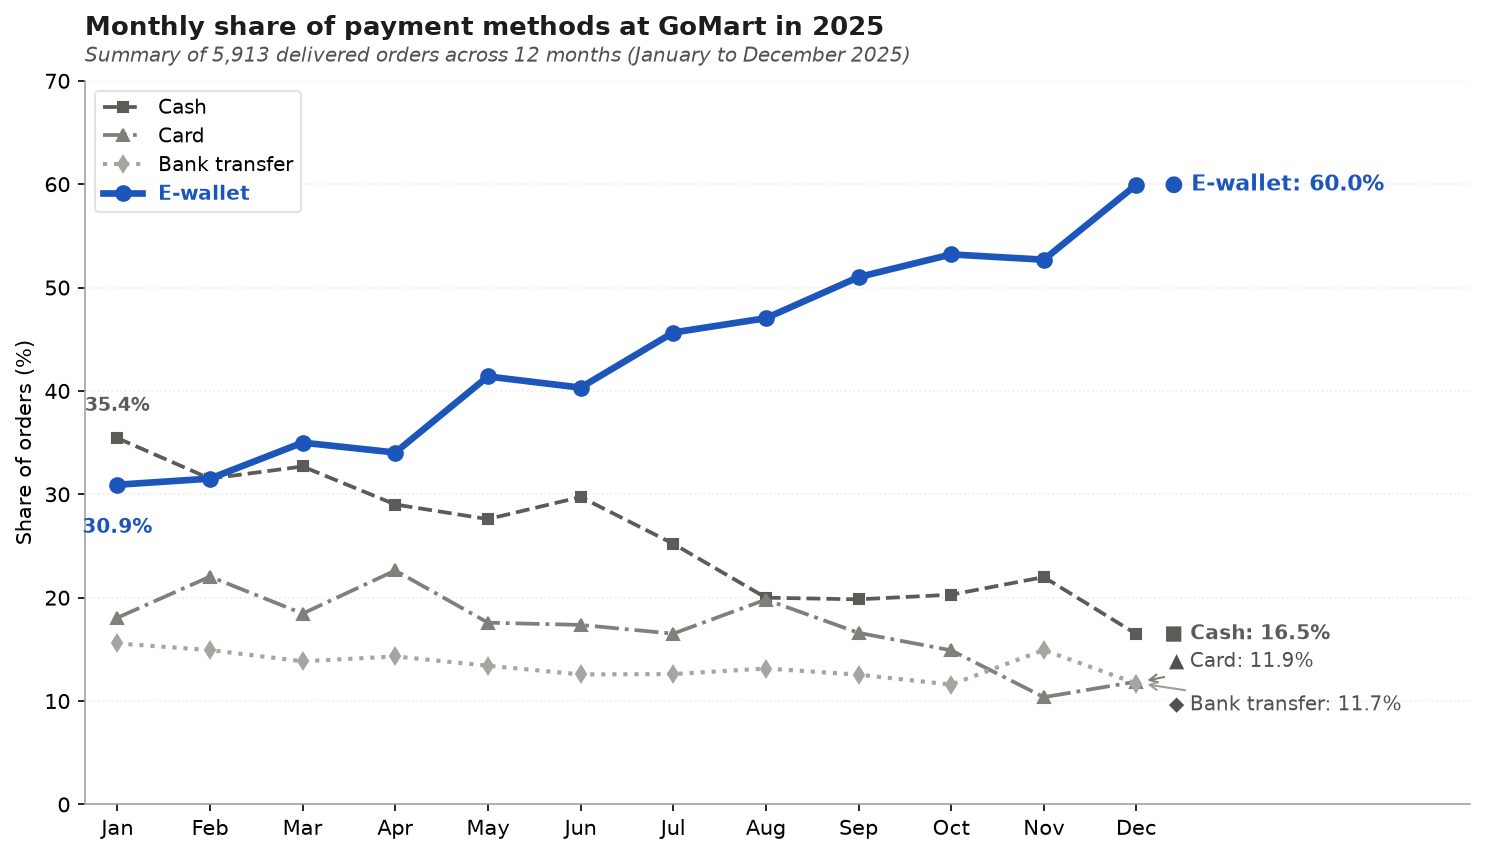

In [23]:
# Monthly share of payment methods at GoMart in 2025 - Line Chart
p = pct_monthly
months = list(range(1, 13))
m_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5.8), dpi=150)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

styles = {
    "Cash":          {"color": "#5c5b57", "ls": "--", "marker": "s", "lw": 1.8, "ms": 5,   "zorder": 3},
    "Card":          {"color": "#807f7a", "ls": "-.", "marker": "^", "lw": 1.8, "ms": 5.5, "zorder": 3},
    "Bank transfer": {"color": "#a6a5a0", "ls": ":",  "marker": "d", "lw": 2.0, "ms": 5.5, "zorder": 3},
    "E-wallet":      {"color": "#1d56ba", "ls": "-",  "marker": "o", "lw": 3.2, "ms": 7,   "zorder": 6},
}

for method, s in styles.items():
    ax.plot(months, p[method], label=method, **s)

# Start annotations (Month 1)
ax.text(1, p["Cash"].iloc[0] + 2.2, f"{p['Cash'].iloc[0]:.1f}%", ha="center", va="bottom", fontsize=9, color="#5c5b57", fontweight="bold")
ax.text(1, p["E-wallet"].iloc[0] - 3.2, f"{p['E-wallet'].iloc[0]:.1f}%", ha="center", va="top", fontsize=9.5, color="#1d56ba", fontweight="bold")

# End annotations (Month 12) with staggered callouts to prevent collision
ax.text(12.3, p["E-wallet"].iloc[-1], f"● E-wallet: {p['E-wallet'].iloc[-1]:.1f}%", va="center", fontsize=10.5, fontweight="bold", color="#1d56ba")
ax.text(12.3, p["Cash"].iloc[-1], f"■ Cash: {p['Cash'].iloc[-1]:.1f}%", va="center", fontsize=9.5, fontweight="bold", color="#5c5b57")
ax.annotate(f"▲ Card: {p['Card'].iloc[-1]:.1f}%", xy=(12.05, p["Card"].iloc[-1]), xytext=(12.35, 13.8),
            va="center", fontsize=9.5, color="#52514e",
            arrowprops=dict(arrowstyle="->", color="#807f7a", lw=1.0, shrinkA=3, shrinkB=3))
ax.annotate(f"◆ Bank transfer: {p['Bank transfer'].iloc[-1]:.1f}%", xy=(12.05, p["Bank transfer"].iloc[-1]), xytext=(12.35, 9.6),
            va="center", fontsize=9.5, color="#52514e",
            arrowprops=dict(arrowstyle="->", color="#9e9d98", lw=1.0, shrinkA=3, shrinkB=3))

# Axis and grid styling
ax.set(xticks=months, xticklabels=m_labels, ylabel="Share of orders (%)", ylim=(0, 70), xlim=(0.65, 15.6))
ax.yaxis.grid(True, linestyle=":", alpha=0.5, color="#d9d8d3")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for s in ["left", "bottom"]: ax.spines[s].set_color("#a3a29d")

leg = ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="#e0dfdb", fontsize=9.5, labelspacing=0.45)
leg.get_texts()[3].set_weight("bold")
leg.get_texts()[3].set_color("#1d56ba")

ax.set_title("Monthly share of payment methods at GoMart in 2025", fontsize=12.5, fontweight="bold", pad=22, loc="left", color="#1d1d1b")
ax.text(0, 1.02, "Summary of 5,913 delivered orders across 12 months (January to December 2025)",
        transform=ax.transAxes, fontsize=9.5, style="italic", color="#52514e", va="bottom")

plt.tight_layout()
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/figures/q2_ewallet_trend.png", dpi=200, bbox_inches="tight")
plt.show()


#### Supporting Chart 1: Total revenue by payment method
*Objective:* Show that e-wallets command the highest total revenue (44.1%, >663M VND), refuting concerns that e-wallets are limited to small baskets.


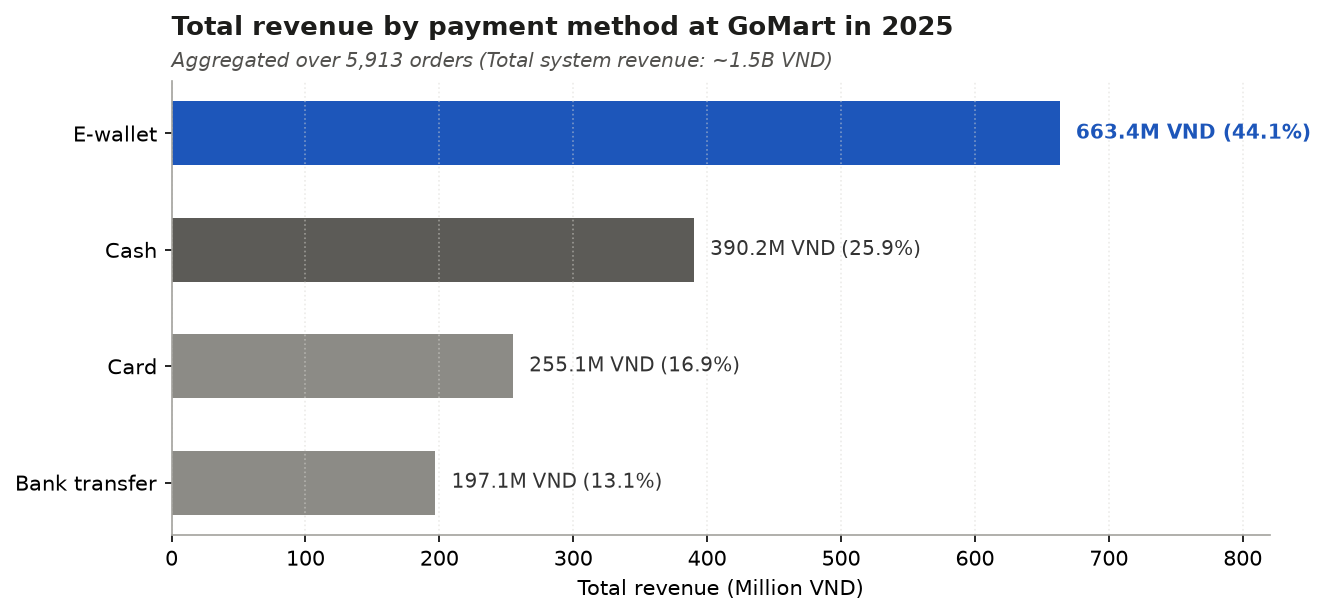

In [24]:
rev = df.groupby("payment")["basket_value_vnd"].sum().reset_index(name="total_rev")
rev["pct"] = rev["total_rev"] / rev["total_rev"].sum() * 100
rev["million_vnd"] = rev["total_rev"] / 1e6
rev = rev.sort_values("total_rev", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.2), dpi=150)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

bars = ax.barh(rev["payment"], rev["million_vnd"], color=["#8c8b86", "#8c8b86", "#5c5b57", "#1d56ba"], height=0.55)
for bar, (_, row) in zip(bars, rev.iterrows()):
    is_ew = (row["payment"] == "E-wallet")
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2,
            f"{row['million_vnd']:,.1f}M VND ({row['pct']:.1f}%)",
            va="center", fontsize=9.5, fontweight="bold" if is_ew else "normal",
            color="#1d56ba" if is_ew else "#333333")

ax.set(xlim=(0, 820), xlabel="Total revenue (Million VND)")
ax.xaxis.grid(True, linestyle=":", alpha=0.5, color="#d9d8d3")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for s in ["left", "bottom"]: ax.spines[s].set_color("#a3a29d")

ax.set_title("Total revenue by payment method at GoMart in 2025", fontsize=12.5, fontweight="bold", pad=22, loc="left", color="#1d1d1b")
ax.text(0, 1.02, "Aggregated over 5,913 orders (Total system revenue: ~1.5B VND)",
        transform=ax.transAxes, fontsize=9.5, style="italic", color="#52514e", va="bottom")

plt.tight_layout()
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/figures/q2_revenue_by_payment.png", dpi=200, bbox_inches="tight")
plt.show()


#### Supporting Evidence 2 · Payment shares across member tiers
*Objective:* Confirm that e-wallet adoption spans all tiers and peaks among Platinum members (49.6%), disproving one-off discount hunting.


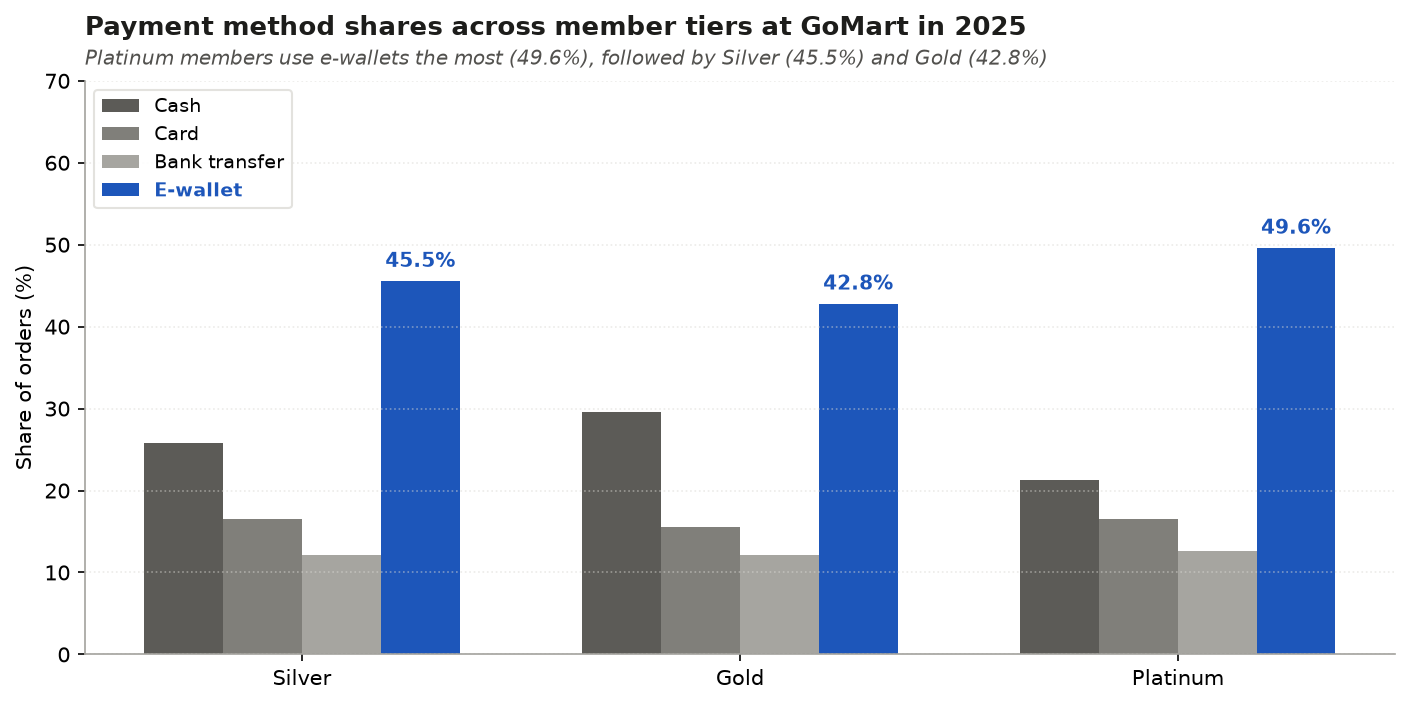

In [25]:
tiers = ["Silver", "Gold", "Platinum"]
x, width = np.arange(len(tiers)), 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
colors = {"Cash": "#5c5b57", "Card": "#807f7a", "Bank transfer": "#a6a5a0", "E-wallet": "#1d56ba"}

fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=150)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

for off, (m, c) in zip(offsets, colors.items()):
    bars = ax.bar(x + off * width, tier_pct.loc[tiers, m], width, label=m, color=c)
    if m == "E-wallet":
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.2, f"{b.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=9.5, fontweight="bold", color=c)

ax.set(xticks=x, xticklabels=tiers, ylabel="Share of orders (%)", ylim=(0, 70))
ax.yaxis.grid(True, linestyle=":", alpha=0.5, color="#d9d8d3")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for s in ["left", "bottom"]: ax.spines[s].set_color("#a3a29d")

leg = ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="#e0dfdb", fontsize=9)
leg.get_texts()[3].set_weight("bold")
leg.get_texts()[3].set_color("#1d56ba")

ax.set_title("Payment method shares across member tiers at GoMart in 2025", fontsize=12.5, fontweight="bold", pad=22, loc="left", color="#1d1d1b")
ax.text(0, 1.02, "Platinum members use e-wallets the most (49.6%), followed by Silver (45.5%) and Gold (42.8%)",
        transform=ax.transAxes, fontsize=9.5, style="italic", color="#52514e", va="bottom")

plt.tight_layout()
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/figures/q2_payment_by_tier.png", dpi=200, bbox_inches="tight")
plt.show()



### Q3 · Do slow deliveries cost good ratings?
*Task: ...  Chart and why: ...*

In [ ]:
# TODO: write your code here

In [ ]:
# TODO: write your code here

*Interpretation:*

### Q4 · When are the peaks?

**Task (action + target):** Identify the weekday–hour slots with the highest order volume to plan rider shifts.

**Chart and why:** A heatmap. It shows both dimensions of the peak pattern at once — which day *and* which hour is busiest — instead of collapsing one of them. X = hour of day (0–23), Y = weekday (Mon → Sun), colour = number of orders (colorbar labelled "Orders"). The full 7 × 24 grid is shown; weekday–hour slots with no order are 0.

Counted on every order line (unique `order_id`) of the cleaned 2025 data — delivered and cancelled alike — so the total matches "orders in 2025"; this is stated in the interpretation below.

In [ ]:
# Q4 - Order peaks by weekday x hour
# Independent of Q1-Q3: use the Task 4 table if present, else read the clean CSV.
df = orders.copy() if "orders" in globals() else pd.read_csv(HERE / "gomart_orders_clean.csv")
from matplotlib.colors import LinearSegmentedColormap

# Re-establish the ordered weekday so rows follow Mon -> Sun even after a CSV round-trip.
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["weekday"] = pd.Categorical(df["weekday"].astype(str).str[:3], DAYS, ordered=True)
df["hour"] = df["hour"].astype(int)

# Orders per weekday x hour, counted on each order line (unique order_id) of the cleaned
# 2025 data. `counts` is a full 7 x 24 table; weekday-hour slots with no order stay 0.
counts = pd.crosstab(df["weekday"], df["hour"]).reindex(index=DAYS, columns=range(24), fill_value=0)

# Consistency checks: the table is 7 x 24 and the plotted total matches the orders fed in.
assert counts.shape == (7, 24), counts.shape
assert int(counts.values.sum()) == df["order_id"].nunique() == len(df)
print("weekday x hour table:", counts.shape, "| orders plotted:", int(counts.values.sum()))

# Find the busiest slot(s) and busiest hour from the table itself (no hard-coded result).
peak_val = int(counts.values.max())
peak_slots = [(d, int(h)) for d in DAYS for h in range(24) if counts.loc[d, h] == peak_val]
hours_rank = counts.sum(axis=0).sort_values(ascending=False)
peak_hour, peak_hour_total = int(hours_rank.index[0]), int(hours_rank.iloc[0])
h2, v2 = int(hours_rank.index[1]), int(hours_rank.iloc[1])
h3, v3 = int(hours_rank.index[2]), int(hours_rank.iloc[2])
peak_desc = ", ".join(f"{d} {h:02d}:00" for (d, h) in peak_slots)
print("peak slot(s):", peak_slots, "=", peak_val,
      "| busiest hour:", peak_hour, f"({peak_hour_total})", "| then", h2, v2, "|", h3, v3)

# ---- Heatmap ----
cmap = LinearSegmentedColormap.from_list("gomart", ["#f4f3ef", "#a9c0e2", "#1d56ba"])
fig, ax = plt.subplots(figsize=(13, 4.8), dpi=150)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

im = ax.imshow(counts.values, aspect="auto", cmap=cmap, origin="upper")

# Outline the peak slot(s).
for (d, h) in peak_slots:
    ax.add_patch(plt.Rectangle((h - 0.5, DAYS.index(d) - 0.5), 1, 1,
                               fill=False, edgecolor="#db7043", linewidth=2.4))

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(DAYS, fontsize=10)
ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", length=0)
ax.set_xlabel("Hour of day (0-23)", fontsize=11)
ax.set_ylabel("Weekday (Mon -> Sun)", fontsize=11)

cbar = fig.colorbar(im, ax=ax, pad=0.015)
cbar.set_label("Orders", fontsize=10)
cbar.outline.set_visible(False)

# Title states the finding computed above; subtitle gives the weekly hour ranking.
ax.set_title(f"Delivery demand peaks at {peak_desc} ({peak_val} orders in one slot)",
             fontsize=13, fontweight="bold", pad=16, loc="left", color="#1d1d1b")
ax.text(0, 1.045,
        f"Across the week {peak_hour:02d}:00 is the busiest hour ({peak_hour_total:,} orders), "
        f"then {h2:02d}:00 ({v2:,}) and {h3:02d}:00 ({v3:,}) - an evening surge with a smaller lunch bump",
        transform=ax.transAxes, fontsize=9.5, style="italic", color="#52514e", va="bottom")
fig.text(0.012, 0.02,
         f"All {len(df):,} cleaned orders for 2025 counted per weekday-hour slot "
         f"(empty cells = 0 orders). Source: gomart_orders_clean.csv (Task 4).",
         ha="left", va="bottom", fontsize=9, style="italic", color="#52514e")

plt.tight_layout()
out_dir = HERE / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "q4_order_peaks.png", dpi=200, bbox_inches="tight")
print("Saved:", out_dir / "q4_order_peaks.png")
plt.show()

*Interpretation:* Order volume concentrates in the evening: the single busiest slot is Tuesday 19:00 (112 orders) and 19:00 is the busiest hour of the week overall (674 orders), with a smaller lunch-time bump at 12:00 (551 orders), so rider shifts should be weighted toward the 18:00–20:00 window; counts include all 5,913 cleaned orders (delivered and cancelled).

## Task 7 · Team and AI
| Member | What they did | Share of work |
|---|---|---|
| | | |

In [ ]:
AI_USE = """
Tool(s) used:
What we asked:
What we checked or changed ourselves:
"""
print(AI_USE)